# Bayesian inference on the Planck 2018 binned TT power spectrum

**Final project — Advanced data & statistical methods lab.**
Reproducible notebook (Option 1: companion to the LaTeX report).

We fit the publicly released Planck 2018 *binned* TT angular power spectrum with
a CAMB-based theoretical model and a simplified per-bin Gaussian likelihood,
sampled with MCMC.

The compute engine (data loading, CAMB theory, priors and likelihood) lives in
the module **`planck_model.py`**. Keeping it in a module — rather than inline —
is what lets the MCMC worker processes import it under the `spawn` start method,
which is required on macOS and avoids the OpenMP + `fork` deadlock.

---
## Step 1 — Setup & data loading

In [11]:
# Step 1: imports and configuration
import os, sys
# one thread per process; set before importing numpy/camb (also done inside the module)
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"
sys.path.insert(0, os.getcwd())          # make planck_model importable (incl. spawn workers)

import numpy as np
import matplotlib.pyplot as plt
import planck_model as pm                 # loads the data and defines the model on import

FIG_DIR, CHAIN_DIR = "figures", "chains"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(CHAIN_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# handy local aliases
ell, Dl, err = pm.ell, pm.Dl, pm.err
theory_dl, log_posterior = pm.theory_dl, pm.log_posterior
NDIM, theta_fid = pm.NDIM, pm.theta_fid
print(f"{len(ell)} bins, ell range {ell.min():.0f}-{ell.max():.0f}")

83 bins, ell range 48-2499


### The Planck 2018 binned TT spectrum
`planck_model.py` downloads `COM_PowerSpect_CMB-TT-binned_R3.01.txt` (Planck PR3
ancillary data) once and caches it. Five columns: effective multipole $\ell$,
bandpower $D_\ell=\ell(\ell+1)C_\ell/2\pi\;[\mu K^2]$, lower/upper $1\sigma$
errors, and the Planck best fit.

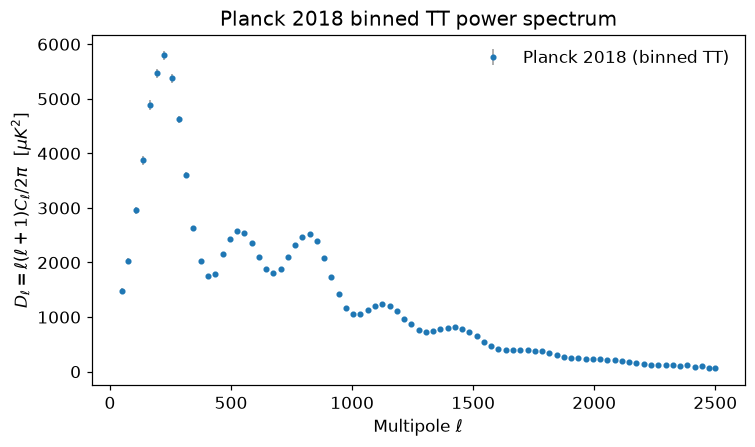

In [12]:
# Step 1: plot the data with error bars
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ell, Dl, yerr=err, fmt="o", ms=3, lw=1,
            color="C0", ecolor="0.6", label="Planck 2018 (binned TT)")
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell=\ell(\ell+1)C_\ell/2\pi\ \ [\mu K^2]$")
ax.set_title("Planck 2018 binned TT power spectrum")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "planck_tt_data.pdf")); plt.show()

---
## Step 2 — Theoretical model with CAMB
`pm.theory_dl(theta)` returns the lensed $D_\ell^{TT}$ for the 6 $\Lambda$CDM
parameters $\theta=(\Omega_b h^2,\Omega_c h^2,H_0,\tau,\ln(10^{10}A_s),n_s)$,
interpolated to the effective multipoles of the data. Massless neutrinos and low
lensing-potential accuracy are used for speed (stated simplifications).

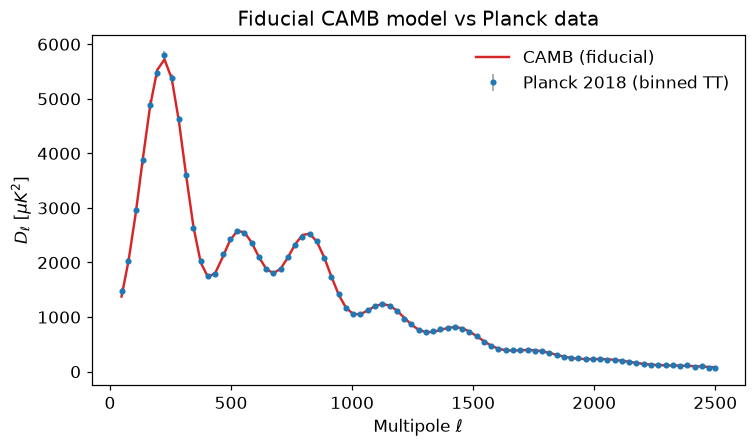

In [13]:
# Step 2: sanity check - theory at Planck 2018 fiducial values vs data
dl_fid = theory_dl(theta_fid)        # theta_fid = [ombh2, omch2, H0, tau, ln10As, ns]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ell, Dl, yerr=err, fmt="o", ms=3, lw=1, color="C0",
            ecolor="0.6", label="Planck 2018 (binned TT)")
ax.plot(ell, dl_fid, "-", color="C3", lw=1.6, label="CAMB (fiducial)")
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell\ [\mu K^2]$")
ax.set_title("Fiducial CAMB model vs Planck data")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "theory_vs_data.pdf")); plt.show()

---
## Step 3 — Likelihood, priors and posterior
Defined in `planck_model.py`: a diagonal Gaussian likelihood
$\ln\mathcal{L}=-\tfrac12\sum_b (D_b-D_b^{\rm th})^2/\sigma_b^2$, flat priors on
five parameters, and a Gaussian prior $\tau\sim\mathcal{N}(0.0544,0.0073^2)$
(Planck lowE) that breaks the $A_s$–$\tau$ degeneracy. CAMB calls are wrapped in
`try/except` so extreme parameters return $-\infty$ instead of crashing a chain.

In [14]:
# Step 3: posterior is finite at the fiducial point
print("log-posterior at fiducial:", round(log_posterior(theta_fid), 2))

log-posterior at fiducial: -44.01


---
## Step 4 — MCMC sampling with `emcee`

Walkers start in a tight Gaussian ball around the fiducial point, run a short
burn-in, reset, then run the production phase; the chain is saved to `chains/`.

**Parallelisation.** Walker evaluations are parallelised with a process `Pool`
using the **`spawn`** start method: each worker imports `planck_model` fresh and
single-threaded. This is essential on this software stack — `fork` deadlocks
because NumPy's OpenBLAS and CAMB both use OpenMP, and forking an active OpenMP
runtime hangs. Progress is written to `chains/progress.log` so it can be
monitored from another cell (`!tail -n 8 chains/progress.log`) regardless of how
Jupyter streams stdout.

In [15]:
# Step 4: sampler configuration and walker initialisation
N_WALKERS = 14       # >= 2*NDIM
N_BURN    = 150      # burn-in steps (discarded)
N_PROD    = 600     # production steps (kept)

INIT_STD = np.array([1e-4, 1e-3, 0.5, 0.002, 0.01, 0.005])   # per-parameter spread
rng = np.random.default_rng(42)
p0 = theta_fid + INIT_STD * rng.standard_normal((N_WALKERS, NDIM))
assert np.all([np.isfinite(log_posterior(p)) for p in p0]), "bad init"
print(f"{N_WALKERS} walkers x {N_BURN}+{N_PROD} steps initialised")

14 walkers x 150+600 steps initialised


In [16]:
# Step 4: run the sampler (parallel, spawn) and save the chain
import emcee, time
import multiprocessing as mp        # stdlib: planck_model funcs pickle by reference under spawn

USE_POOL = True
PROGRESS_FILE = os.path.join(CHAIN_DIR, "progress.log")

def _log(msg):
    """Print AND append to a file, so progress is visible even if Jupyter does
    not stream stdout live during a long cell."""
    line = f"{time.strftime('%H:%M:%S')}  {msg}"
    print(line, flush=True)
    with open(PROGRESS_FILE, "a") as f:
        f.write(line + "\n")

def run_sampler(pool=None):
    s = emcee.EnsembleSampler(N_WALKERS, NDIM, log_posterior, pool=pool)
    _log(f"start burn-in ({N_BURN} steps)")
    for i, _ in enumerate(s.sample(p0, iterations=N_BURN), 1):
        if i == 1 or i % 20 == 0:
            _log(f"burn-in {i}/{N_BURN}")
    state = s.get_last_sample(); s.reset()
    _log(f"start production ({N_PROD} steps)")
    for i, _ in enumerate(s.sample(state, iterations=N_PROD), 1):
        if i == 1 or i % 20 == 0:
            _log(f"prod {i}/{N_PROD}")
    return s

open(PROGRESS_FILE, "w").close()                       # reset the log
if USE_POOL:
    with mp.get_context("spawn").Pool() as pool:       # spawn: no OpenMP/fork deadlock
        sampler = run_sampler(pool)
else:
    sampler = run_sampler()

chain = sampler.get_chain()                            # (N_PROD, N_WALKERS, NDIM)
log_prob = sampler.get_log_prob()
np.save(os.path.join(CHAIN_DIR, "chain.npy"), chain)
np.save(os.path.join(CHAIN_DIR, "log_prob.npy"), log_prob)
np.save(os.path.join(CHAIN_DIR, "acceptance.npy"), sampler.acceptance_fraction)
print("mean acceptance fraction:",
      round(float(np.mean(sampler.acceptance_fraction)), 3))

12:13:00  start burn-in (150 steps)
12:13:51  burn-in 1/150
12:20:00  burn-in 20/150
12:26:17  burn-in 40/150
12:31:35  burn-in 60/150
12:36:53  burn-in 80/150
12:42:32  burn-in 100/150
12:48:23  burn-in 120/150
12:54:09  burn-in 140/150
12:57:03  start production (600 steps)
12:57:18  prod 1/600
13:02:25  prod 20/600
13:08:07  prod 40/600
13:13:26  prod 60/600
13:19:01  prod 80/600
13:28:59  prod 100/600
13:35:04  prod 120/600
13:41:00  prod 140/600
13:46:55  prod 160/600
13:52:48  prod 180/600
13:58:59  prod 200/600
14:04:07  prod 220/600
14:08:39  prod 240/600
14:11:59  prod 260/600
14:15:36  prod 280/600
14:19:29  prod 300/600
14:23:43  prod 320/600
14:28:18  prod 340/600
14:32:57  prod 360/600
14:37:22  prod 380/600
14:41:31  prod 400/600
14:45:40  prod 420/600
14:49:57  prod 440/600
14:54:37  prod 460/600
14:59:03  prod 480/600
15:04:33  prod 500/600
15:10:09  prod 520/600
15:17:11  prod 540/600
15:22:15  prod 560/600
15:27:24  prod 580/600
15:32:40  prod 600/600
mean acceptance 

---
## Step 5 — Convergence diagnostics

This step only **loads** `chains/chain.npy` (no re-sampling), so it can be run
once the production chain has been saved. We use three standard checks:
- **Walker traces:** should fluctuate around stationary values with no drift.
- **Acceptance fraction:** healthy in the $0.2$–$0.5$ range for the stretch move.
- **Integrated autocorrelation time** $\tau$: the ratio $N/\tau$ (chain length
  over $\tau$) estimates the number of independent samples per walker; as a rule
  of thumb $N/\tau\gtrsim50$ is well converged, $\gtrsim20$ usually acceptable.

In [17]:
# Step 5: load the chain and quantify convergence
import emcee
chain = np.load(os.path.join(CHAIN_DIR, "chain.npy"))        # (nsteps, nwalkers, ndim)
log_prob = np.load(os.path.join(CHAIN_DIR, "log_prob.npy"))
nsteps, nwalkers, ndim = chain.shape
NAMES = ["ombh2", "omch2", "H0", "tau", "ln10As", "ns"]

# integrated autocorrelation time per parameter (quiet=True: estimate even if short)
tau = emcee.autocorr.integrated_time(chain, quiet=True)
print(f"production steps: {nsteps}, walkers: {nwalkers}")
for n, t in zip(NAMES, tau):
    print(f"  {n:7s} tau ~ {t:5.1f}   N/tau ~ {nsteps / t:5.1f}")

acc_path = os.path.join(CHAIN_DIR, "acceptance.npy")
if os.path.exists(acc_path):
    print(f"mean acceptance fraction: {np.load(acc_path).mean():.3f}  (healthy ~0.2-0.5)")

The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 12;
tau: [25.97425359 35.75804395 32.36976689 42.58870248 45.17422077 35.66575163]


production steps: 600, walkers: 14
  ombh2   tau ~  26.0   N/tau ~  23.1
  omch2   tau ~  35.8   N/tau ~  16.8
  H0      tau ~  32.4   N/tau ~  18.5
  tau     tau ~  42.6   N/tau ~  14.1
  ln10As  tau ~  45.2   N/tau ~  13.3
  ns      tau ~  35.7   N/tau ~  16.8
mean acceptance fraction: 0.523  (healthy ~0.2-0.5)


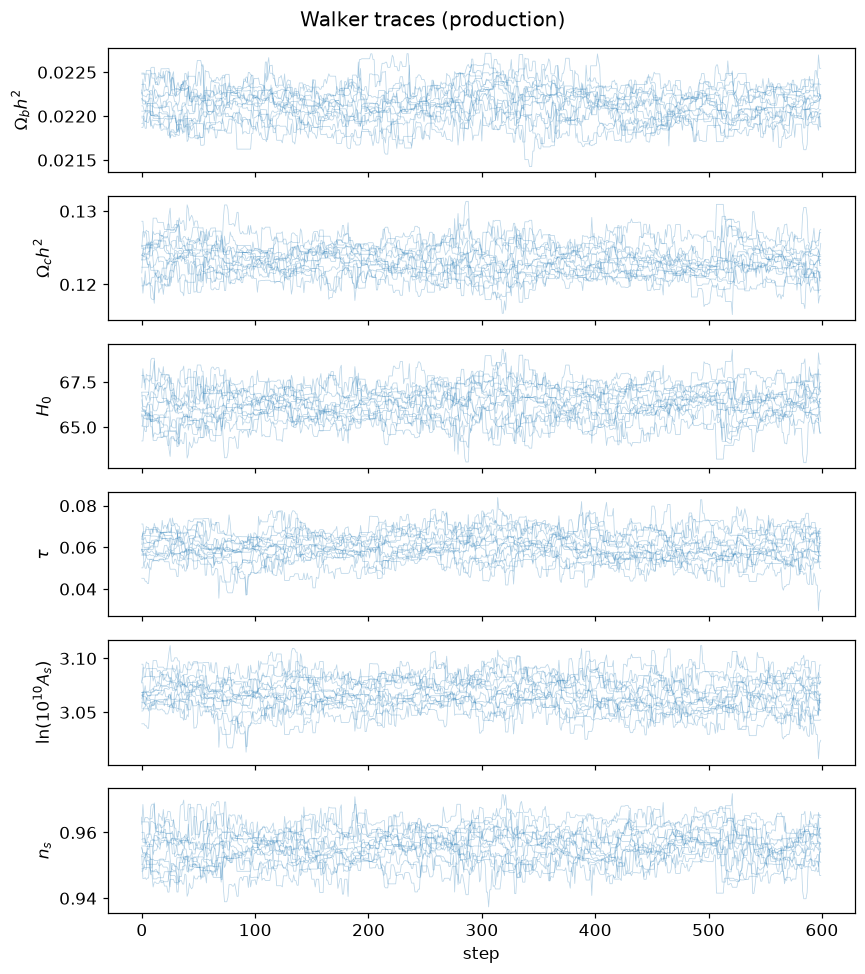

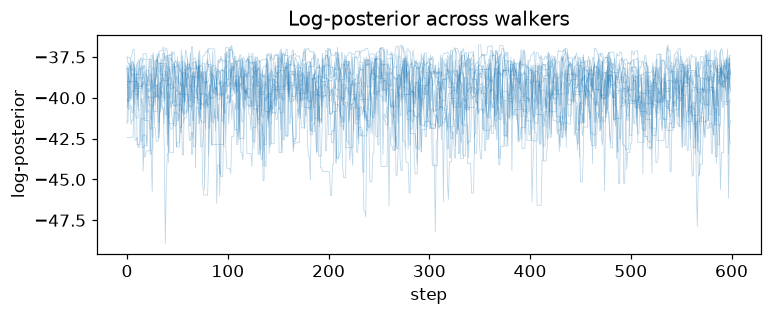

In [18]:
# Step 5: walker traces and log-posterior trace
LBL = [r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$H_0$", r"$\tau$",
       r"$\ln(10^{10}A_s)$", r"$n_s$"]
fig, axes = plt.subplots(ndim, 1, figsize=(8, 1.5 * ndim), sharex=True)
for k in range(ndim):
    axes[k].plot(chain[:, :, k], color="C0", alpha=0.3, lw=0.5)
    axes[k].set_ylabel(LBL[k])
axes[-1].set_xlabel("step")
fig.suptitle("Walker traces (production)"); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "traces.pdf")); plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(log_prob, color="C0", alpha=0.3, lw=0.5)
ax.set_xlabel("step"); ax.set_ylabel("log-posterior")
ax.set_title("Log-posterior across walkers"); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "logprob_trace.pdf")); plt.show()

---
## Step 6 — Posteriors, credible intervals and best fit

We flatten the production chain (burn-in already removed in Step 4) into a set of
posterior samples, summarise each parameter by its median and $16$/$84$-th
percentile ($1\sigma$) credible interval, and show the joint posterior as a
corner plot with the fiducial values marked. Finally we overlay the posterior
median model on the data and report the $\chi^2$ per degree of freedom.

parameter      median     -1sigma   +1sigma
  ombh2       0.0221    0.0002    0.0002
  omch2       0.1232    0.0020    0.0022
  H0         66.3198    0.9688    0.9080
  tau         0.0601    0.0062    0.0071
  ln10As      3.0665    0.0140    0.0158
  ns          0.9560    0.0055    0.0050


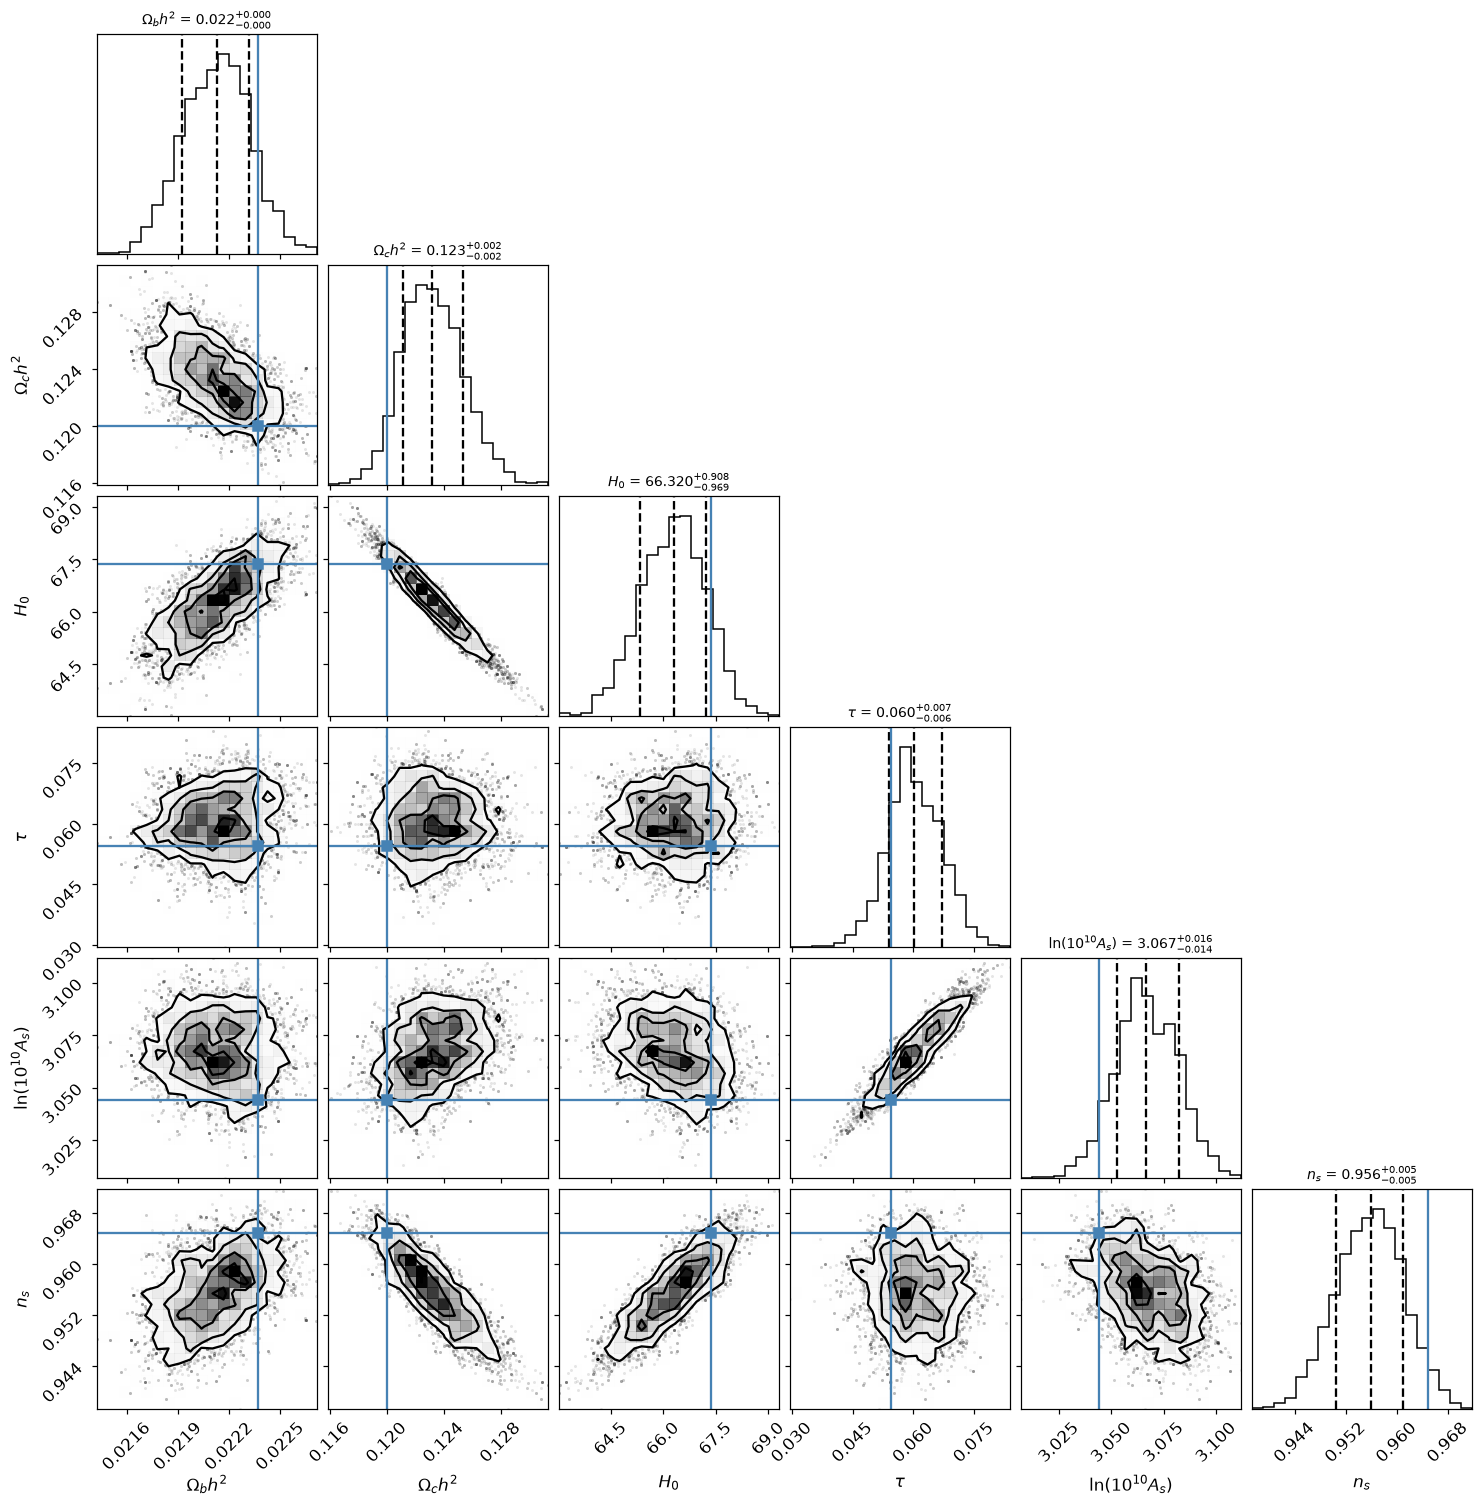

In [19]:
# Step 6: flatten the chain, credible intervals, corner plot
import corner
flat = chain.reshape(-1, ndim)               # burn-in already removed in Step 4
LBL = [r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$H_0$", r"$\tau$",
       r"$\ln(10^{10}A_s)$", r"$n_s$"]

qs = np.percentile(flat, [16, 50, 84], axis=0)   # 1-sigma credible interval
print("parameter      median     -1sigma   +1sigma")
for n, lo, med, hi in zip(NAMES, qs[0], qs[1], qs[2]):
    print(f"  {n:7s}  {med:9.4f}  {med-lo:8.4f}  {hi-med:8.4f}")

fig = corner.corner(flat, labels=LBL, truths=theta_fid,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_fmt=".3f", title_kwargs={"fontsize": 9})
fig.savefig(os.path.join(FIG_DIR, "corner.pdf")); plt.show()

chi2 = 72.7,  dof = 77,  chi2/dof = 0.94


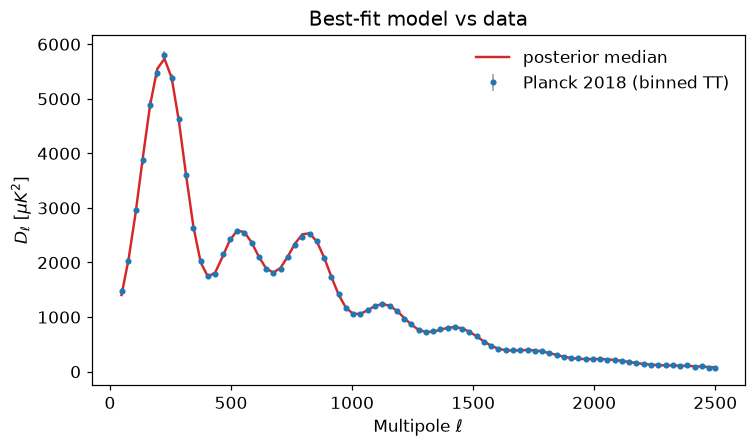

In [20]:
# Step 6: posterior-median model vs data + goodness of fit
theta_med = np.median(flat, axis=0)
dl_best = theory_dl(theta_med)
chi2 = np.sum(((Dl - dl_best) / err) ** 2)
dof = len(ell) - ndim
print(f"chi2 = {chi2:.1f},  dof = {dof},  chi2/dof = {chi2/dof:.2f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ell, Dl, yerr=err, fmt="o", ms=3, lw=1, color="C0",
            ecolor="0.6", label="Planck 2018 (binned TT)")
ax.plot(ell, dl_best, "-", color="C3", lw=1.6, label="posterior median")
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell\ [\mu K^2]$")
ax.set_title("Best-fit model vs data"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "bestfit.pdf")); plt.show()

---
## Next steps (to be filled)
- **Step 7** — Model variations / robustness.